In [1]:
import marker_utils
import scanpy as sc
import marker_utils.save_data as save_data

In [2]:
# Ensure that the obs in the data contains a celltype entry to indicate the cluster to which each cell belongs. 
# Additionally, the obsm should include a spatial entry to provide spatial information.
sc.read_h5ad('./example_data/spatial_rna.h5ad')

AnnData object with n_obs × n_vars = 2686 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'domain', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [3]:
# Run with the default parameters.
info,adata=marker_utils.get_spatial_MarkersEI('example_data/spatial_rna.h5ad')

------Loading data------


------Data transposition------
2686 cells, 32285 genes.
------Step1: Calculate PCA------
------Step2: Calculate the similarity matrix------
------Step3: Adjust the expression value------
------Step4: Calculate EI------


cluster:Pyramidal_layer_dentate_gyrusrunningcalculate_EI(6/6): 100%|█| 15/15 [4:

4.48 seconds used for calculate_mean_and_var.
14876.24 seconds used for calculate_smoothness.
0.66 seconds used for calculate_V.
22.70 seconds used for calculate_prop.
211.33 seconds used for calculate_local_mean_max.
0.67 seconds used for calculate_EI.
------Congratulations, success!------


In [4]:
# Print the first six Features.
six_features=info['Thalamus_1'].sort_values(by='EI', ascending=False).head(6)['Features'].tolist()
info['Thalamus_1'].sort_values(by='EI', ascending=False).head(6).reset_index(drop=True)

,Features,Mean,Smoothness,Local_max,V,Prop,Prop_sum,P,EI
0,Rab37,2.076630,0.006792,0.800000,634.910059,4.123890e+31,5.300583e+16,0.293233,4.365453e-03
1,Tnnt1,9.567051,0.000379,1.533333,241246.341534,3.972723e+41,1.550954e+31,0.546875,2.672630e-05
2,Vipr2,0.793104,0.020738,0.400000,30.330797,2.004366e+19,8.910338e+06,0.119048,8.524836e-07
3,Hcn4,0.800767,0.012184,1.333333,52.628542,1.341131e+24,1.524538e+12,0.213542,2.415651e-07
4,Abhd12b,1.003832,0.017900,1.400000,56.295552,2.929216e+20,4.116744e+08,0.151042,1.961360e-07
5,Gpr4,0.919541,0.013608,2.133333,62.135129,9.142708e+23,8.199709e+11,0.205882,1.808886e-07


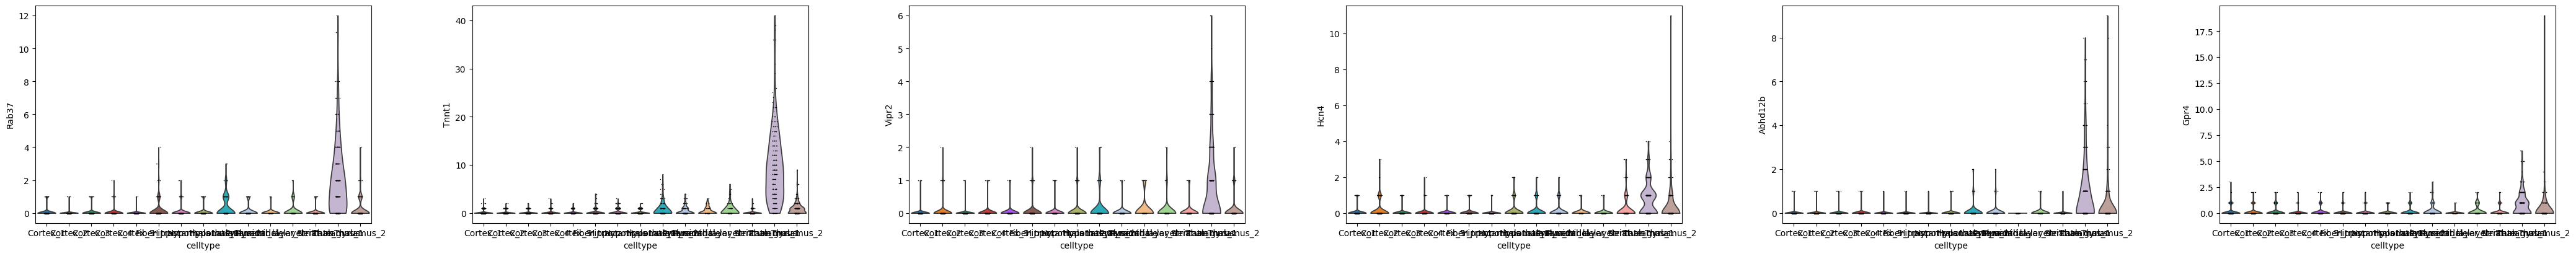

In [5]:
sc.pl.violin(adata,six_features,groupby="celltype")

In [6]:
# Obtain cluster-specific differentially expressed genes
sc.pp.log1p(adata)
sc.tl.rank_genes_groups(adata, groupby="celltype", method="wilcoxon")
sc.get.rank_genes_groups_df(adata, group="Thalamus_1").head(6)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Prkcd,25.589800,5.173906,1.981461e-144,6.397148e-140
1,Rora,25.484085,3.361544,2.959432e-143,4.777263e-139
2,Adarb1,25.163834,2.913728,9.972917e-140,1.073252e-135
3,Ramp3,24.800575,3.745033,8.837834e-136,7.133237e-132
4,Tnnt1,24.571129,5.125908,2.571884e-133,1.660666e-129
5,Amotl1,24.461760,3.416048,3.772821e-132,2.030092e-128


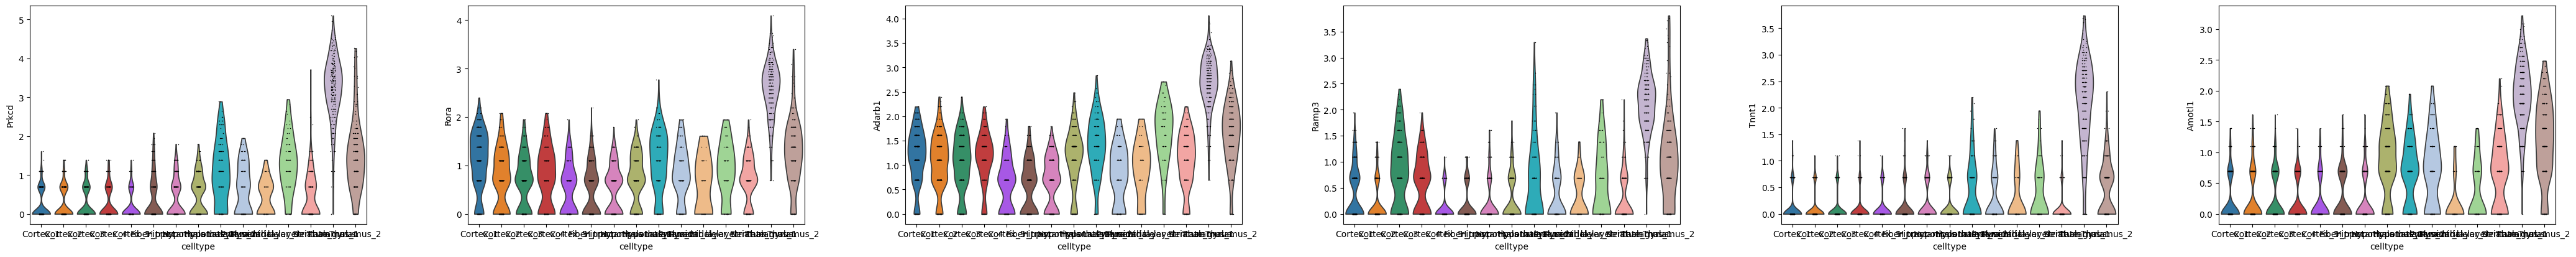

In [7]:
sc.pl.violin(adata,sc.get.rank_genes_groups_df(adata, group="Thalamus_1").head(6)['names'].tolist(),groupby="celltype")